# Midterm Project

## Introduction

#### This report will cover 3 distinct curve-fitting methods on a selected dataset to compare and evaluate accuracy, error, and performance relative to one another. The dataset being used presents the seasonally adjusted annual rate (SAAR) of real GDP growth of the United States in %. Selected quarters range from 2010 Q1 to 2023 Q4, with 20 distinct quarters being selected throughout this range. The source of this data is the U.S. Bureau of Economic Analysis (BEA). The three curve-fitting methods I will apply are the Least Squares Linear Regression model, the Polynomial Fitting model via Vandermonde Matrices and Normal Equations, and the Natural Cubic Spline Interpolation.

In [2]:
#Initialize all relevant libraries:
import numpy as np
import matplotlib.pyplot as plt

In [25]:
#initialize data from the table
quarterSteps = np.array([0, 4, 8, 12, 16, 18, 21, 24, 26, 27, 28, 32, 
                         36, 40, 41, 42, 44, 48, 53, 55], dtype=float)
gdpGrowth = np.array([1.7, 0.1, 2.3, 2.7, 1.7, 5.0, 3.0, 1.5, 
                      3.5, 1.8, 1.3, 2.5, 3.1, -5.1, -28.1, 33.8, 6.3, -1.6, 2.4, 3.3], dtype=float)

# Part A

### Algorithms needed to construct a custom natural cubic spline interpolant

In [26]:
# Cubic Spline Custom Algorithms
def setup_tridiagonal_matrix(x, y):
    n = len(x)
    h = np.diff(x)  # Step 2: Calculates the step sizes in between each x value
    # Initialize the tridiagonal matrix coefficients
    A = np.zeros(n - 2)  # Subdiagonal
    B = np.zeros(n - 2)  # Main diagonal
    C = np.zeros(n - 2)  # Superdiagonal
    D = np.zeros(n - 2)  # Right-hand side vector
    # Populate the tridiagonal matrix coefficients
    for i in range(1, n - 1):
        A[i - 1] = h[i-1]             # Subdiagonal
        B[i - 1] = 2*(h[i-1]+h[i])    # Main diagonal
        C[i - 1] = h[i]             # Superdiagonal
        D[i - 1] = 6 * ((y[i+1]-y[i]) / h[i] - (y[i]-y[i-1])/h[i-1])             # Right-hand side vector
    return A, B, C, D

def thomas_algorithm(a, b, c, d):
    """
    Solve the tridiagonal system using the Thomas algorithm.
    a: sub-diagonal elements (length n-1)
    b: main diagonal elements (length n)
    c: super-diagonal elements (length n-1)
    d: right-hand side (length n)
    Returns: solution vector x of length n
    """
    n = len(b)
    # Forward elimination
    for i in range(1, n):
        w = a[i-1] / b[i-1]
        b[i] = b[i] - w * c[i-1]
        d[i] = d[i] - w * d[i-1]
    # Back substitution
    x = np.zeros(n)
    x[-1] = d[-1] / b[-1]
    for i in range(n-2, -1, -1):
        x[i] = (d[i] - c[i] * x[i+1]) / b[i]
    return x

def evaluate_spline(x_data, y_data, M, x_query):
    # This function evaluates the spline using the second derivatives at every point given.
    n = len(x_data)
    h = np.diff(x_data) # step sizes
    i = np.searchsorted(x_data, x_query, side='right') - 1
    i = np.clip(i, 0, n - 2) # find interval
    hi = h[i]
    dx_left = x_query - x_data[i] # (x - xᵢ)
    dx_right = x_data[i+1] - x_query # (xᵢ₊₁ - x)
    S = (
    (M[i] / (6*hi)) * dx_right**3 + # Term 1
    (M[i+1] / (6*hi)) * dx_left**3 + # Term 2
    (y_data[i] /hi - M[i] *hi/6) * dx_right + # Term 3
    (y_data[i+1] /hi - M[i+1] *hi/6) * dx_left # Term 4
    )
    return S

### Part A, 1

In [115]:
#tridiagonal matrix setup for the custom cubic spline 
A, B, C, D = setup_tridiagonal_matrix(quarterSteps, gdpGrowth)
TridiagonalMatrix = np.diag(B) + np.diag(A[:-1], k=-1) + np.diag(C[:-1], k=1)
#the resulting tridiagonal matrix (note the 18x18 size, which matches the size of the column of the unknowns we need to solve)
print("Tridiagonal Matrix w/o RHS:")
print(f"A: {TridiagonalMatrix}")
print(f"n size: {len(TridiagonalMatrix)}")
print("\n")

#condition number check
condition = np.linalg.cond(TridiagonalMatrix)
print(f"Condition Number: {condition}")
print("\n")

# Thomas algorithm calculation of M_inner and added boundary conditions
M_inner = thomas_algorithm(A, B, C, D)
M = np.concatenate(([0], M_inner, [0])) #Natural boundary conditions are added to ensure M1 = Mn = 0
print(f"M: {M} \n")

#Spline evaluation:
x_interp = np.linspace(0, 55, 1000)
y_interp = evaluate_spline(quarterSteps, gdpGrowth, M, x_interp)

Tridiagonal Matrix w/o RHS:
A: [[16.  4.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 4. 16.  4.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  4. 16.  4.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  4. 12.  2.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  4. 10.  3.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  2. 12.  3.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  3. 10.  2.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  3.  6.  1.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  2.  4.  1.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  1. 10.  4.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  0.  1. 16.  4.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  4. 16.  4.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  4. 10.  1.  0.  0.  0.

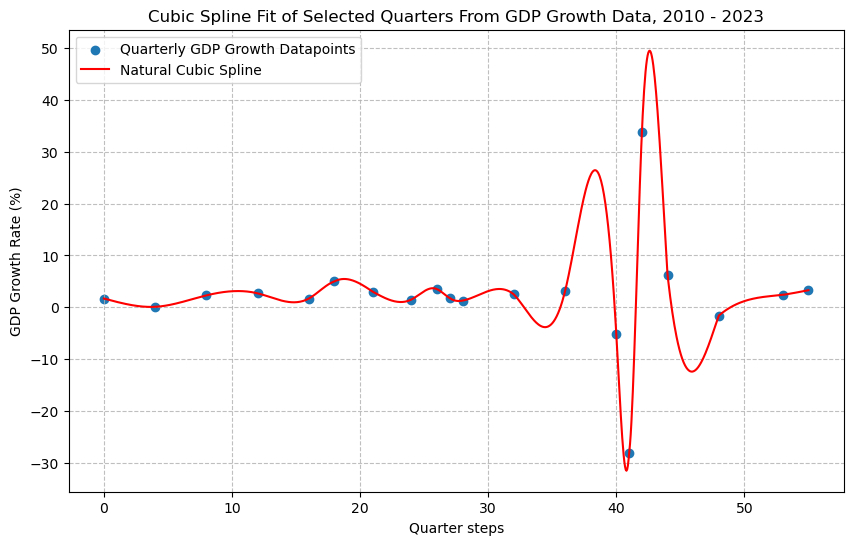

In [116]:
#plot of the cubic spline fitting of the given dataset:
plt.figure(figsize=(10, 6))
plt.scatter(quarterSteps, gdpGrowth, label="Quarterly GDP Growth Datapoints")
plt.plot(x_interp, y_interp, 'r-', label="Natural Cubic Spline")
plt.title("Cubic Spline Fit of Selected Quarters From GDP Growth Data, 2010 - 2023")
plt.xlabel("Quarter steps")
plt.ylabel("GDP Growth Rate (%)")
plt.grid(True, linestyle="--", alpha=0.8)
plt.legend()
plt.show()

### Discussion:

#### My method uses the second derivative method, or "M" Method to construct the spline. This algorithm sets up a system of equations to solve for the second derivatives Mi at each knot. In total, there are 20 data points, and because the method used is a natural cubic spline, we know that the derivatives M1 and M20 are fixed by the boundary conditions. Thus, only the second derivatives at the interior knots are unknown. In this case, there are 18 unknowns that the function must solve for, and this perfectly matches the 18x18 size of the Tridiagonal Matrix, as shown above in the code.
#### The system ensures that the interpolated curve is smooth by first checking if the first derivatives are equal or not to prevent sharp corners from appearing. Next, the system checks if the end of one polynomial is connected to the beginning of the next polynomial, ensuring that there are no gaps. Finally, the system checks if the second derivatives are equal in order to preserve the transition from one interval to the next.

#### The most important characteristic of a natural cubic spline is that the second derivatives assigned to the first and last knots are exactly zero. Essentially, this means that the curve flattens out to zero as it approaches and interacts with these two points. 

### Part A, 2

In [117]:
#Spline evaluation at every quarter in the full range
x_fullRange = np.arange(0, 56)
y_fullRange = evaluate_spline(quarterSteps, gdpGrowth, M, x_fullRange)

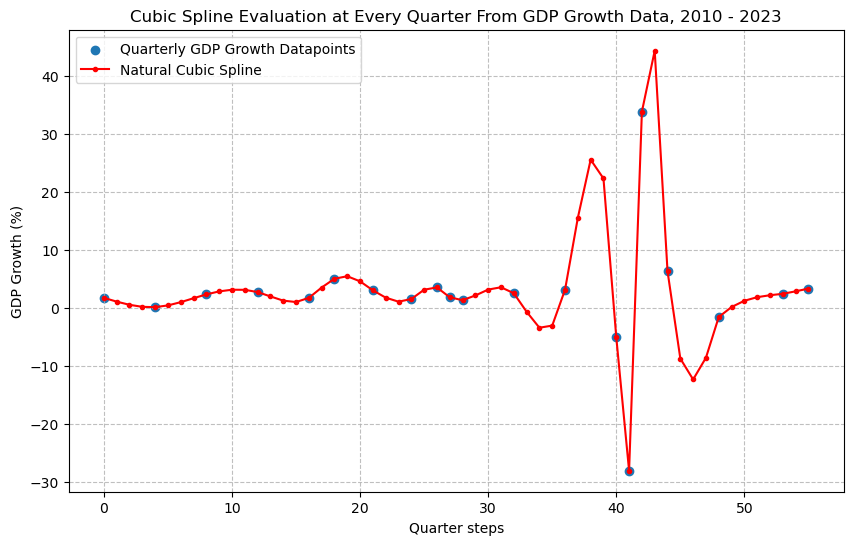

In [118]:
#Cubic spline fitting at every quarter (0 to 55) in the full range:
plt.figure(figsize=(10, 6))
plt.scatter(quarterSteps, gdpGrowth, label="Quarterly GDP Growth Datapoints")
plt.plot(x_fullRange, y_fullRange, 'ro-', markersize=3, label="Natural Cubic Spline ")
plt.title("Cubic Spline Evaluation at Every Quarter From GDP Growth Data, 2010 - 2023")
plt.xlabel("Quarter steps")
plt.ylabel("GDP Growth (%)")
plt.grid(True, linestyle="--", alpha=0.8)
plt.legend()
plt.show()

### Discussion:

#### Visually, the curve looks relatively smooth until it approaches the outlier datapoints, where it suddenly becomes jagged, resulting in two distinct peaks and a very sharp valley, before returning to a smoother trajectory. Mathematically, the interpolation is strictly mathematically smooth because of the maintenance of polynomial continuity with no sharp corners. The abrupt change in visual smoothness is caused by a phenomenon called spline ringing, in which the curve oscillates widely between the outlier GDP growth data, resulting in a visually less smooth curve.

#### The interpolation itself is not reasonable, especially near the outlier data points. Looking at the graph, there is an unprecedented surge in GDP growth in quarters 37-39, before crashing rapidly in quarter 41 and swinging up with even greater intensity towards quarter 43. This type of interpolation fails the "eye test," where the interpolation itself is likely unreasonable and overfitting to the data. Economically, this also makes little sense, as GDP growth did not suddenly skyrocket before the COVID recession. In this case, while the spline perfectly interpolates the data, it fails as a predictive model because it prioritizes smoothness and fitting exactly to the data over a general trend in GDP, resulting in local distortions that do not reflect the overall trend. 

## Part A, 3

### Discussion:

#### The Runge phenomenon is the phenomenon where interpolations using high-degree polynomials cause massive, uncontrollable oscillations at the edges of the dataset. Although cubic splines were invented to solve the Runge phenomenon across the entire dataset by using low-degree piecewise polynomials, cubic splines can still be subjected to localized instances of Runge phenomena when they encounter outlier data. As evidenced by the cubic spline interpolations of the data above, the spline experiences massive oscillations by attempting to fit every data point and creating artificial noise that likely does not exist in the overall trend. 
#### To account for outliers using exact interpolation, the dataset must have zero error at the data points. In this case, numerical stability is sacrificed for accuracy, because the model will fit exactly to the data, even though the data will always contain noise of some sort. Thus, this model results in inaccurate fits and predictions. On the other hand, numerical stability abandons exact interpolation by creating a model that has a predictable and consistent trend. The trade-off is that it cannot fit every data point.
#### To produce the best possible cubic spline fit for the data, the requirement that the model must fit to every data point can be slightly relaxed to incorporate numerical stability. The first method that can be used is the smoothing spline, where a penalty parameter is assigned to help minimize the distance to the data points and minimize the curvature of the line. This method allows the user to control how much the spline flexes while still fitting to the data. Another method that can be used is the weighted least squares method, where a user assigns a weight to certain quarters to allow the model to either fit more or fit less to certain data points. Although both methods are better than a natural cubic spline, a smoothing spline is likely the best tool because it still incorporates piecewise polynomials to fit more subtle shifts in the economy, while accounting for outliers and keeping the model stable.

# Part B

### Algorithm for Polyfit:

In [148]:
#This function calculates the polynomial coefficients for the polyfit least squares method
def Custom_Polyfit(x, y, degree):
    #Vandermond Matrixes
    V = np.vander(x, N=degree+1, increasing=True)
    # V.T * V
    VT_V = np.dot(V.T, V)
    # V.T * y
    VT_y = np.dot(V.T, y)
    # Solve for a (coefficients)
    coefficients = np.linalg.solve(VT_V, VT_y)
    polynomial = np.poly1d(coefficients[::-1])
    return polynomial

### Algorithm for Residuals:

In [170]:
#This function calculates useful residuals such as MSE, RMSE, and r_squared.
def residuals(y, y_pred):
    mse = np.mean((y - y_pred)**2)
    print(f'Mean Squared Error: {mse:.16f}')
    rmse = np.sqrt(mse)
    print(f'RMSE: {rmse:.16f}')
    ss_total = np.sum((y - np.mean(y))**2)
    ss_res = np.sum((y - y_pred)**2)
    r_squared = 1 - (ss_res / ss_total)
    print(f'R-squared: {r_squared:.16f}')
    return mse, rmse, r_squared

## Part B, 1

In [171]:
#Creating the polyfit of degree 4 interpolation for the dataset
polyfitCoeff = Custom_Polyfit(quarterSteps, gdpGrowth, 4)
y_polyfit = polyfitCoeff(quarterSteps)

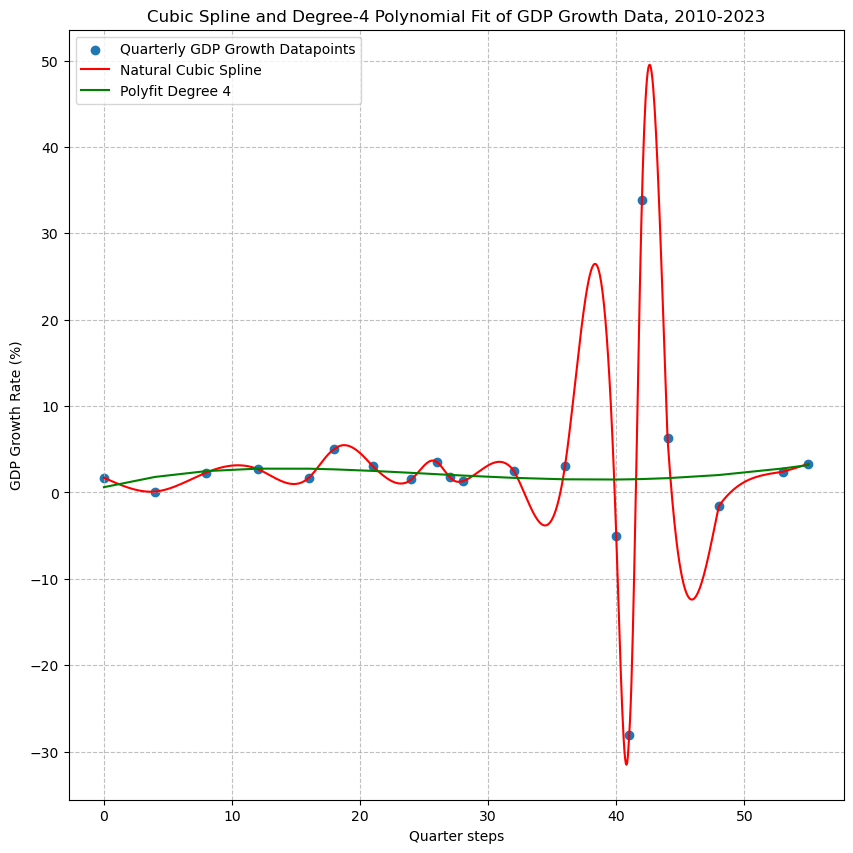

In [172]:
#plot of the cubic spline and degree-4 polynomial fit of the dataset.
plt.figure(figsize=(10, 10))
plt.scatter(quarterSteps, gdpGrowth, label="Quarterly GDP Growth Datapoints")
plt.plot(x_interp, y_interp, 'r-', label="Natural Cubic Spline")
plt.plot(quarterSteps, y_polyfit, 'g', label="Polyfit Degree 4")
plt.title("Cubic Spline and Degree-4 Polynomial Fit of GDP Growth Data, 2010-2023")
plt.xlabel("Quarter steps")
plt.ylabel("GDP Growth Rate (%)")
plt.grid(True, linestyle="--", alpha=0.8)
plt.legend()
plt.show()

### Residuals for Polyfit:

In [173]:
polyfit_mse, polyfit_rmse, polyfit_rsquared = residuals(gdpGrowth, y_polyfit)

Mean Squared Error: 100.6298020898179857
RMSE: 10.0314406786771162
R-squared: 0.0035410151185397


### Residuals for Cubic Spline (not very useful since it fits exactly to the data points at each knot, resulting in an error that is very very close to zero because of machine epsilon):

In [174]:
y_predCubicSpline = evaluate_spline(quarterSteps, gdpGrowth, M, quarterSteps)
cubic_mse, cubic_rmse, cubic_rsquared =  residuals(gdpGrowth, y_predCubicSpline)

Mean Squared Error: 0.0000000000000000
RMSE: 0.0000000000000010
R-squared: 1.0000000000000000


### Discussion:

#### The model that best captures the overall trend is the degree 4 polynomial approximation. This is because this method is specifically used as an approximation method based on least squares, allowing it to capture the general trend of the data without hitting the outliers. As shown above, the green line that represents the polyfit approximation ignores the economic shocks created by COVID to accurately reflect the long-term trend of GDP growth over the time period.
#### On the other hand, the model that better reproduces specific data points is the natural cubic spline. In this case, the cubic spline is mathematically built to fit perfectly to every data point, or knot, provided in the data set. As shown by the residual errors, the cubic spline had an RSME extremely close to zero with noise from machine epsilon, reflecting how it perfectly fit and reproduced every specific point, including the massive drops and rises in GDP. Contrarily, the polynomial had an RSME of 10.03, which reflects how it misses specific points. 
#### The trade-offs between approximation and interpolation are essentially the argument between being super accurate locally and reflecting a broader trend. With interpolation via the cubic spline, global stability is sacrificed for perfect accuracy of the curve at every point, resulting in continuous smoothness yet extreme oscillations around local outlier data points. This creates artificial noise that likely does not exist and is terrible for predictions. On the other hand, approximation through a polynomial fit sacrifices a perfect fit in exchange for a good, stable representation of the overall GDP trend. The trade-offs of each essentially help the model accomplish different tasks, whether to get a better understanding of an overall trend or fit exactly to the data.

## Part B, 2

### Algorithm for Least Squares Linear Approximation

In [185]:
#This function calculates the slope and intercept of a least squares linear approximation of a dataset.
def leastSquaresLinearApprox(x, y):
    A = np.vstack([x, np.ones(len(x))]).T
    m, c = np.linalg.lstsq(A, y, rcond=None)[0]
    return m, c

In [189]:
#dataset with removed COVID quarters
quarterSteps = np.array([0, 4, 8, 12, 16, 18, 21, 24, 26, 27, 28, 32, 
                         36, 48, 53, 55], dtype=float)
gdpGrowth = np.array([1.7, 0.1, 2.3, 2.7, 1.7, 5.0, 3.0, 1.5, 
                      3.5, 1.8, 1.3, 2.5, 3.1, -1.6, 2.4, 3.3], dtype=float)

#calculates the slope and intercept of the approximation
slope, intercept = leastSquaresLinearApprox(quarterSteps, gdpGrowth)
print(f'The slope of the fit is: {slope}')
print(f'The intercept of the fit is: {intercept}')
print('\n')

#Calculate the residuals to be used in the residual graph, as well as the interpolated y values
y_LSLA = slope * quarterSteps + intercept
LSLAresiduals = gdpGrowth - y_LSLA

#Calculate relevant errors
LSLA_mse, LSLA_rmse, LSLA_rsquared = residuals(gdpGrowth, y_LSLA)

The slope of the fit is: -0.00190698818897635
The intercept of the fit is: 2.192378198818898


Mean Squared Error: 2.0827872400959646
RMSE: 1.4431864883291987
R-squared: 0.0004432944068257


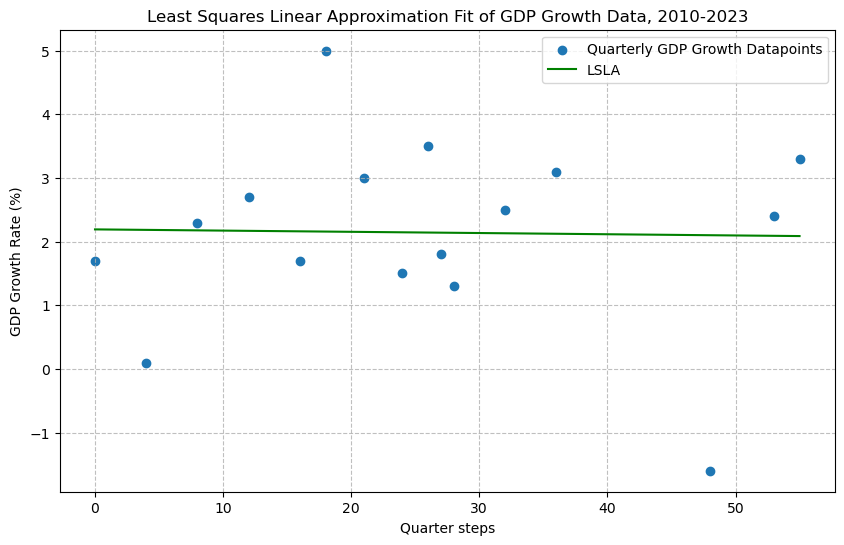

In [192]:
# graph of the interpolation
# plot of the least squares linear approx fit of the dataset.
plt.figure(figsize=(10, 6))
plt.scatter(quarterSteps, gdpGrowth, label="Quarterly GDP Growth Datapoints")
plt.plot(quarterSteps, y_LSLA, 'g', label="LSLA")
plt.title("Least Squares Linear Approximation Fit of GDP Growth Data, 2010-2023")
plt.xlabel("Quarter steps")
plt.ylabel("GDP Growth Rate (%)")
plt.grid(True, linestyle="--", alpha=0.8)
plt.legend()
plt.show()

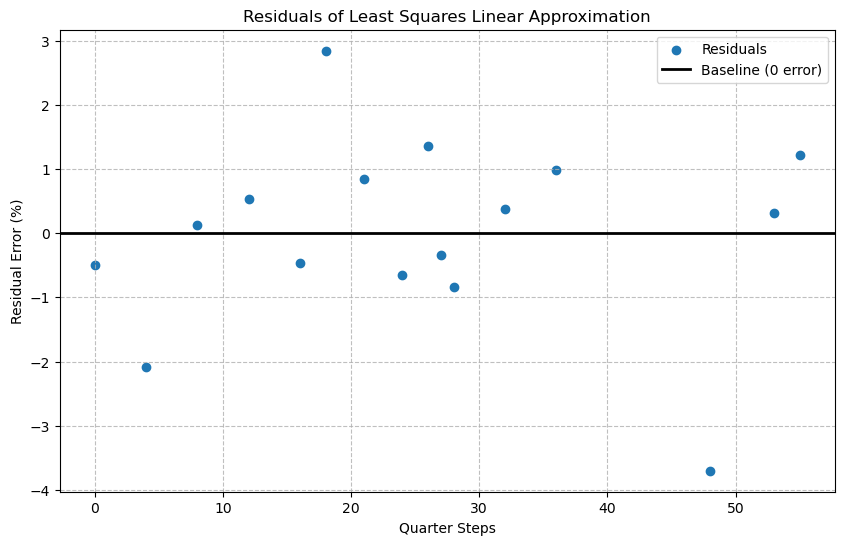

In [193]:
# graph of the residuals
plt.figure(figsize=(10, 6))
plt.scatter(quarterSteps, LSLAresiduals, label="Residuals")
plt.axhline(y=0, color='black', linewidth=2, label="Baseline (0 error)")
plt.title("Residuals of Least Squares Linear Approximation")
plt.xlabel("Quarter Steps")
plt.ylabel("Residual Error (%)")
plt.grid(True, linestyle="--", alpha=0.8)
plt.legend()
plt.show()

### Discussion:

#### The slope of the graph is -0.0019. 

#### A linear trend makes economic sense for the data. The flat horizontal line shown in the graphs above indicates that the US economy is growing steadily over time. In general, the US economy has had a long-term real GDP growth rate of about 2-4% during "normal" cycles of the economy (excluding recessions and booms). This best-fit line shows exactly that, hovering around 2.3%, which is a good representation of the normal GDP growth rate of the US. Additionally, the residual plot supports the idea that the line is the best-fitting tool, as the residual points do not suggest that a straight line is the wrong shape for the baseline data.

#### Fitting the least squares approximation line requires a few assumptions. The biggest assumption is that the economic shock due to COVID is a temporary phenomenon that did not vastly reshape how GDP has grown or will grow over the next few years. Other assumptions assume that the US economy is operating in the same way in 2023 as it did in 2010, the underlying trend of the data is a straight line, and noise within the normal economic data remains generally consistent over time (no increase or decrease in general noise).

# Part 3

### Discussion:

#### I would recommend the cubic spline model to the policymaker for interpolation between two known data points to estimate GDP growth for an unknown quarter. This is because the policymaker is specifically looking for a model that can provide the best local approximation between two distinct points, and the cubic spline model is the model specifically built for such interpolation. In terms of accuracy, the cubic spline is mathematically built to pass perfectly through the two quarters the policymaker provides. This results in a very good estimate of the local data. Additionally, polynomial fitting fails to pass through specific data points, as shown by the RMSE error close to 10. In terms of smoothness, a cubic spline guarantees C2 continuity (up to second derivatives), allowing the model to interpolate without creating sharp or noisy edges. Additionally, since it is piecewise, the local fit is vastly more accurate than a global fit that is specifically constrained to these two data points. The polynomial performs worse here, since the smoothness ignores localized features. Finally, in terms of outliers, the cubic spline is very sensitive and will fit to outliers and oscillate wildly, providing a rather inaccurate spline fit. On the other hand, polynomial fits are far less sensitive. 

#### My specific recommendation to the policymaker is to use the cubic spline when the economy is normal and not experiencing a shock of some sort (recession/boom). If there is a severe outlier close to or at one of the quarter data points, the policymaker should look for alternative methods, such as the smoothing spline discussed earlier, that limits artificial oscillations.

### Big O Analysis:

#### Big O notation is a mathematical concept used to describe how runtime grows as the complexity of an algorithm grows.
#### The natural cubic spline is O(n) and O(logn) for data finding, the Big O of the least squares polynomial is O(N) and O(1) for data finding.
#### This does not change my recommendation, since Big O only matters for large computations. Since O(1) and O(logn) are only relevant for finding one data point, and there are only a limited amount of quarterly points (around 400), the amount of time of computation is virtually negligible in the decision.

# Conclusion:

#### In analyzing the GDP growth data provided by the BEA, the natural cubic spline proved to be the most accurate model for interpolation, as it perfectly fits to every datapoint. However, this results in a severe limitation where it has a sensitivity to extreme outliers, leading to violent oscillations due to the COVID-19 shock. On the other hand, least squares approximation for both polynomial and linear approximations performed best for long-term trend approximation. These methods prioritize the global trend over accuracy and capture the general growth of the US GDP. However, these methods also have the limitation of failing to address events such as the COVID 19 economic crisis. Ultimately, these results perfectly represents the trade-offs between exact interpolation and a reliable overall trend that results from these methods.